# ZARA - Monthly Demand Forecast (XGBoost)

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

## Load data from the Gold layer

In [2]:
load_dotenv(dotenv_path="../src/.env")
engine = create_engine(os.getenv("DATABASE_URL"))

query = """
SELECT
    CAST(d.year AS INT)  AS year,
    CAST(d.month AS INT) AS month,
    p.category,
    CAST(SUM(f.quantity) AS INT) AS total_quantity,
    SUM(f.quantity) FILTER (WHERE f.promo_id IS NOT NULL)::float
        / NULLIF(SUM(f.quantity), 0)     AS promo_share,
    SUM(f.discount_amount)::float
        / NULLIF(SUM(f.gross_amount), 0) AS discount_rate
FROM gold.fact_sales f
JOIN gold.dim_date     d ON f.date_key   = d.date_key
JOIN gold.dim_products p ON f.product_id = p.product_id
WHERE f.source_system = 'batch'   -- historical batch only; keeps the training set
                                  -- reproducible and free of live-stream (2026) rows
GROUP BY d.year, d.month, p.category
ORDER BY p.category, d.year, d.month;
"""

df = pd.read_sql(query, engine)
print(df.shape)
df.head()

(432, 6)


,year,month,category,total_quantity,promo_share,discount_rate
0,2023,1,Bags,612,0.986928,0.292042
1,2023,2,Bags,317,NaN,-0.001310
2,2023,3,Bags,609,NaN,-0.000526
3,2023,4,Bags,605,NaN,-0.000491
4,2023,5,Bags,478,NaN,-0.001139


## Preprocessing

In [3]:
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str))
df = df.sort_values(["category", "date"]).reset_index(drop=True)
df[["promo_share", "discount_rate"]] = df[["promo_share", "discount_rate"]].fillna(0)
df.head()

,year,month,category,total_quantity,promo_share,discount_rate,date
0,2023,1,Bags,612,0.986928,0.292042,2023-01-01
1,2023,2,Bags,317,0.000000,-0.001310,2023-02-01
2,2023,3,Bags,609,0.000000,-0.000526,2023-03-01
3,2023,4,Bags,605,0.000000,-0.000491,2023-04-01
4,2023,5,Bags,478,0.000000,-0.001139,2023-05-01


## Feature engineering

In [4]:
q = df.groupby("category")["total_quantity"]
df["lag_1"]  = q.shift(1)
df["lag_2"]  = q.shift(2)
df["lag_3"]  = q.shift(3)
df["lag_12"] = q.shift(12)                      # year-ago (annual seasonality)

df["rolling_3"] = q.transform(lambda s: s.shift(1).rolling(3).mean())
df["rolling_6"] = q.transform(lambda s: s.shift(1).rolling(6).mean())

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["time_index"] = (df["year"] - df["year"].min()) * 12 + (df["month"] - 1)

df = df.dropna().reset_index(drop=True)
print(df.shape)
df.head()

(288, 16)


,year,month,category,total_quantity,promo_share,discount_rate,date,lag_1,lag_2,lag_3,lag_12,rolling_3,rolling_6,month_sin,month_cos,time_index
0,2024,1,Bags,746,0.975871,0.288730,2024-01-01,943.0,823.0,654.0,612.0,806.666667,734.666667,0.500000,8.660254e-01,12
1,2024,2,Bags,412,0.000000,0.001081,2024-02-01,746.0,943.0,823.0,317.0,837.333333,723.000000,0.866025,5.000000e-01,13
2,2024,3,Bags,643,0.000000,0.001240,2024-03-01,412.0,746.0,943.0,609.0,700.333333,714.666667,1.000000,6.123234e-17,14
3,2024,4,Bags,682,0.000000,-0.000855,2024-04-01,643.0,412.0,746.0,605.0,600.333333,703.500000,0.866025,-5.000000e-01,15
4,2024,5,Bags,576,0.000000,0.001076,2024-05-01,682.0,643.0,412.0,478.0,579.000000,708.166667,0.500000,-8.660254e-01,16


## Categorical encoding

In [5]:
df_enc = pd.get_dummies(df, columns=["category"])
feature_cols = [c for c in df_enc.columns if c not in ["total_quantity", "date", "year"]]
print(len(feature_cols), "features")
feature_cols

24 features


['month',
 'promo_share',
 'discount_rate',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_12',
 'rolling_3',
 'rolling_6',
 'month_sin',
 'month_cos',
 'time_index',
 'category_Bags',
 'category_Coats',
 'category_Dresses',
 'category_Hoodies',
 'category_Jackets',
 'category_Jeans',
 'category_Pants',
 'category_Shirts',
 'category_Shoes',
 'category_Skirts',
 'category_T-Shirts',
 'category_Tops']

## Train / test split (time-based)

In [6]:
split_date = df_enc["date"].quantile(0.8)
train = df_enc[df_enc["date"] <= split_date]
test  = df_enc[df_enc["date"] >  split_date]

X_train, y_train = train[feature_cols], train["total_quantity"]
X_test,  y_test  = test[feature_cols],  test["total_quantity"]
print(f"train={len(train)}  test={len(test)}  split={split_date.date()}")

train=240  test=48  split=2025-08-01


In [7]:
model = XGBRegressor(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

## Evaluation

In [8]:
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAE : {mae:.1f}")
print(f"RMSE: {rmse:.1f}")
print(f"MAPE: {mape:.1f}%")

MAE : 121.0
RMSE: 240.6
MAPE: 8.9%


In [9]:
# Per-category accuracy on the test set
res = test[["date"]].copy()
cat_cols = [c for c in test.columns if c.startswith("category_")]
res["category"]  = test[cat_cols].idxmax(axis=1).str.replace("category_", "")
res["actual"]    = y_test.values
res["predicted"] = y_pred
res["abs_err"]   = (res["actual"] - res["predicted"]).abs()
res["ape"]       = (res["abs_err"] / res["actual"]).abs()
per_cat = (res.groupby("category")
             .agg(MAE=("abs_err", "mean"), MAPE_pct=("ape", lambda s: s.mean()*100))
             .sort_values("MAE").round(1))
per_cat

,MAE,MAPE_pct
category,,
T-Shirts,21.7,19.1
Pants,26.7,14.2
Bags,50.8,4.7
Jeans,53.9,4.9
Tops,55.5,3.0
Shoes,57.8,10.1
Hoodies,61.7,14.1
Shirts,68.3,4.0
Dresses,116.2,5.4


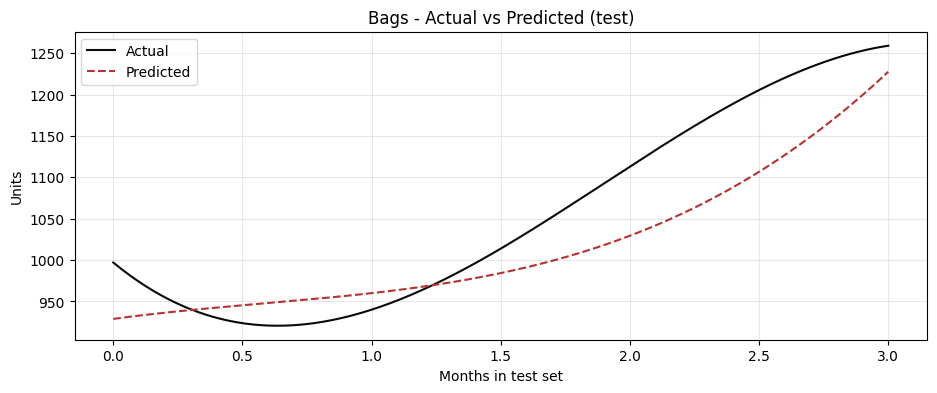

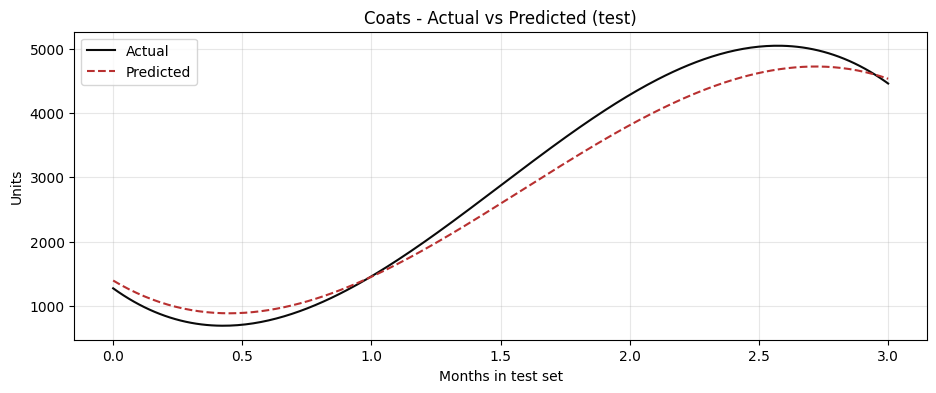

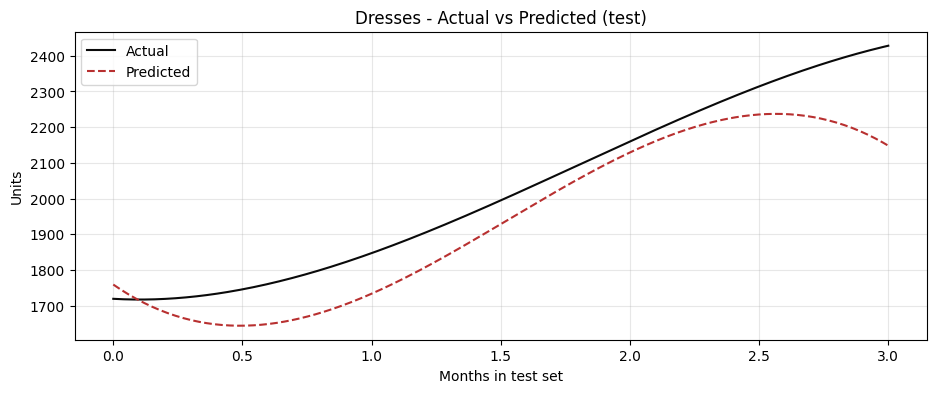

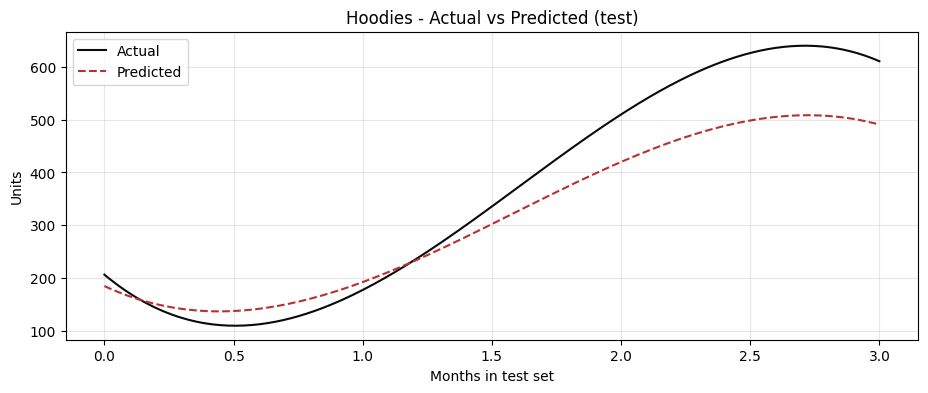

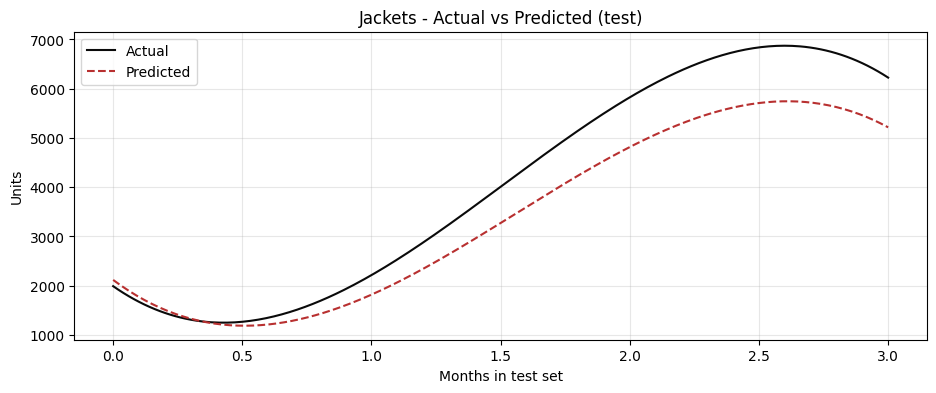

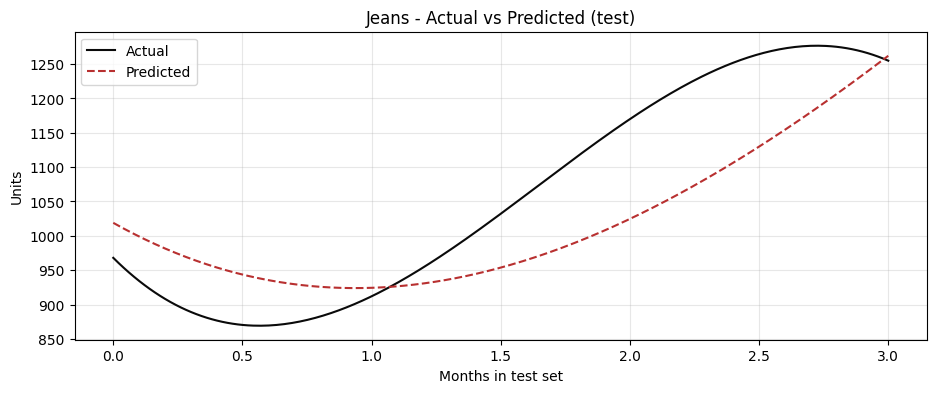

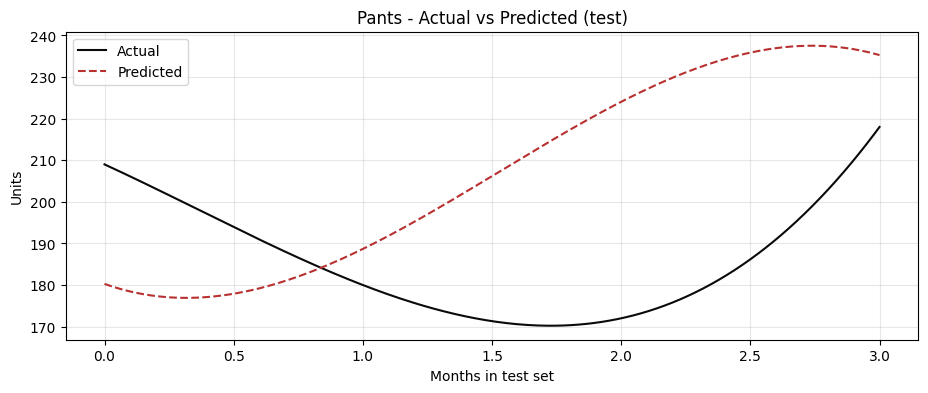

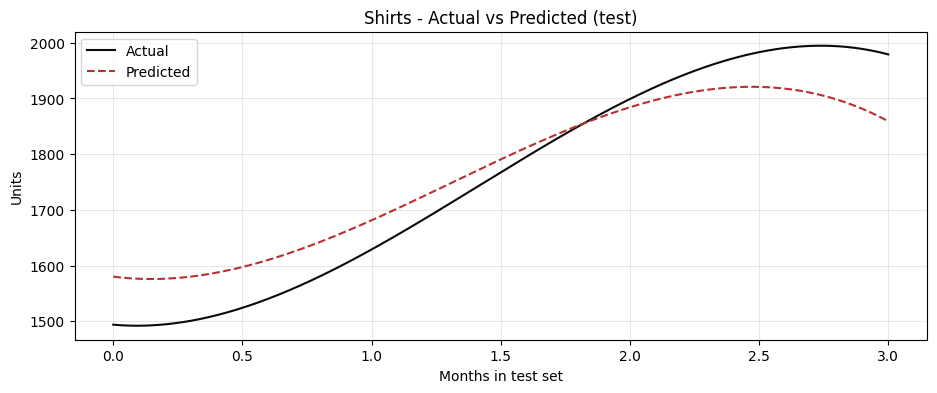

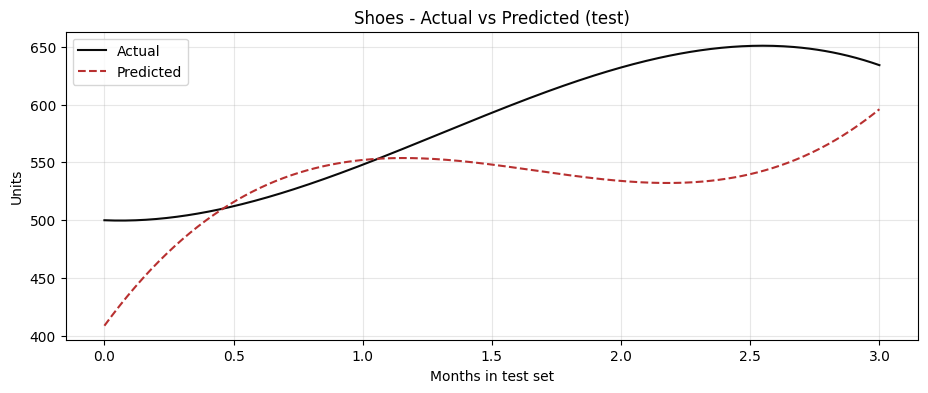

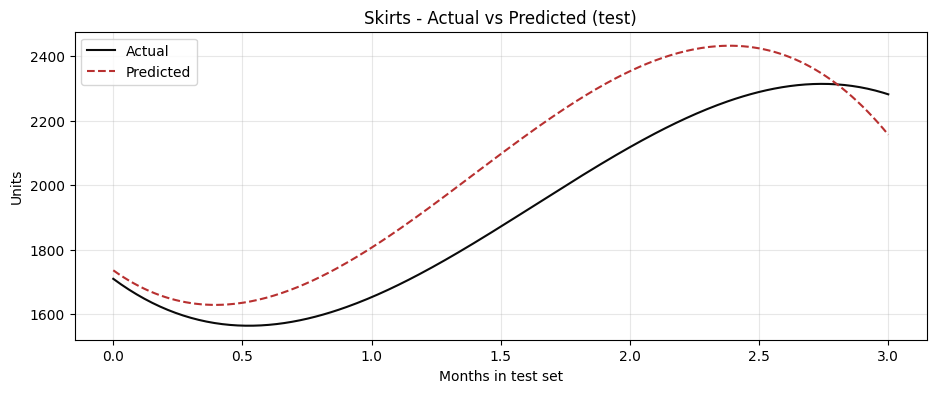

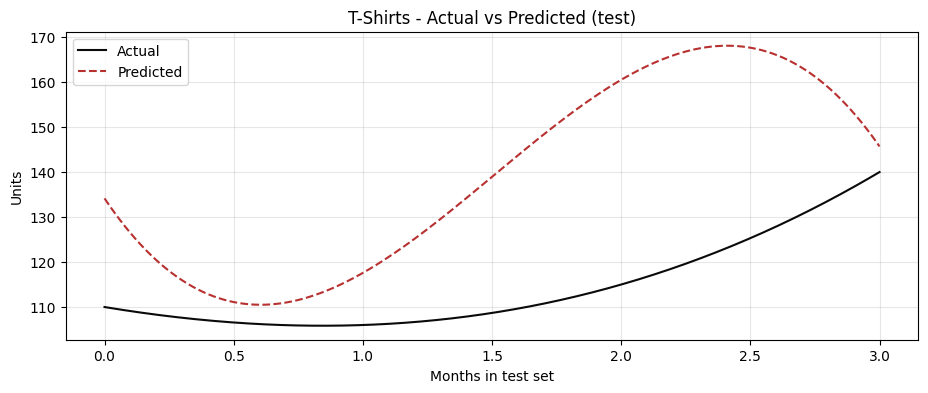

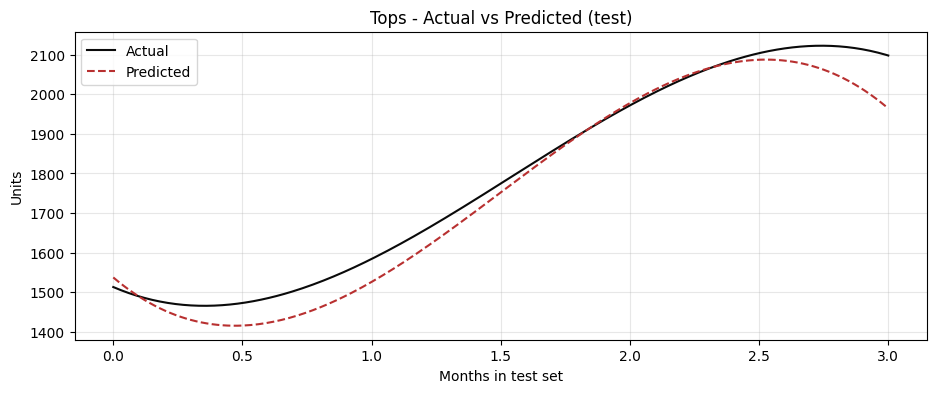

In [10]:
# Actual vs predicted per category (test set)
for cat in sorted(res["category"].unique()):
    temp = res[res["category"] == cat].sort_values("date")
    if len(temp) < 4:
        continue
    x  = np.arange(len(temp))
    xs = np.linspace(x.min(), x.max(), 300)
    ya = make_interp_spline(x, temp["actual"], k=3)(xs)
    yp = make_interp_spline(x, temp["predicted"], k=3)(xs)
    plt.figure(figsize=(11, 4))
    plt.plot(xs, ya, label="Actual", color="#0a0a0a")
    plt.plot(xs, yp, label="Predicted", color="#b83030", linestyle="--")
    plt.title(f"{cat} - Actual vs Predicted (test)")
    plt.xlabel("Months in test set"); plt.ylabel("Units"); plt.legend(); plt.grid(alpha=.3); plt.show()

## Forward forecast - next 6 months

In [11]:
HORIZON = 6
future_rows = []
for cat in sorted(df["category"].unique()):
    s = df[df["category"] == cat].sort_values("date")
    qty = list(s["total_quantity"].values)
    last_date = s["date"].max()
    cal = (s.assign(m=s["date"].dt.month)
             .groupby("m")[["promo_share", "discount_rate"]].last())
    for h in range(1, HORIZON + 1):
        nd = last_date + pd.DateOffset(months=h)
        m = nd.month
        ps = float(cal["promo_share"].get(m, 0.0))
        dr = float(cal["discount_rate"].get(m, 0.0))
        feat = {
            "month": m,
            "lag_1": qty[-1], "lag_2": qty[-2], "lag_3": qty[-3],
            "lag_12": qty[-12] if len(qty) >= 12 else float(np.mean(qty)),
            "rolling_3": float(np.mean(qty[-3:])), "rolling_6": float(np.mean(qty[-6:])),
            "month_sin": np.sin(2*np.pi*m/12), "month_cos": np.cos(2*np.pi*m/12),
            "time_index": (nd.year - df["year"].min())*12 + (m-1),
            "promo_share": ps, "discount_rate": dr,
        }
        row = {c: 0 for c in feature_cols}
        for k, v in feat.items():
            if k in row: row[k] = v
        cd = f"category_{cat}"
        if cd in row: row[cd] = 1
        pred = float(model.predict(pd.DataFrame([row])[feature_cols])[0])
        qty.append(pred)
        future_rows.append({"date": nd, "category": cat, "forecast": max(pred, 0)})

future = pd.DataFrame(future_rows)
future.head(12)

,date,category,forecast
0,2026-01-01,Bags,959.196594
1,2026-02-01,Bags,622.262573
2,2026-03-01,Bags,888.525879
3,2026-04-01,Bags,901.084412
4,2026-05-01,Bags,863.084351
5,2026-06-01,Bags,879.431641
6,2026-01-01,Coats,3537.705322
7,2026-02-01,Coats,1937.451904
8,2026-03-01,Coats,1481.518921
9,2026-04-01,Coats,1524.514771


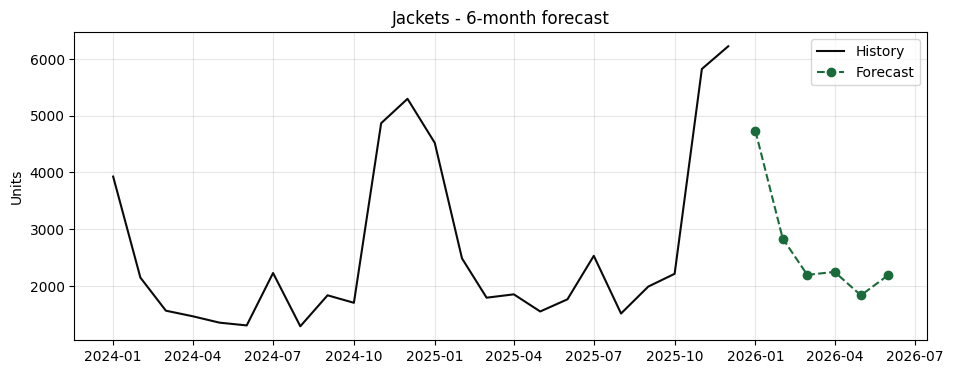

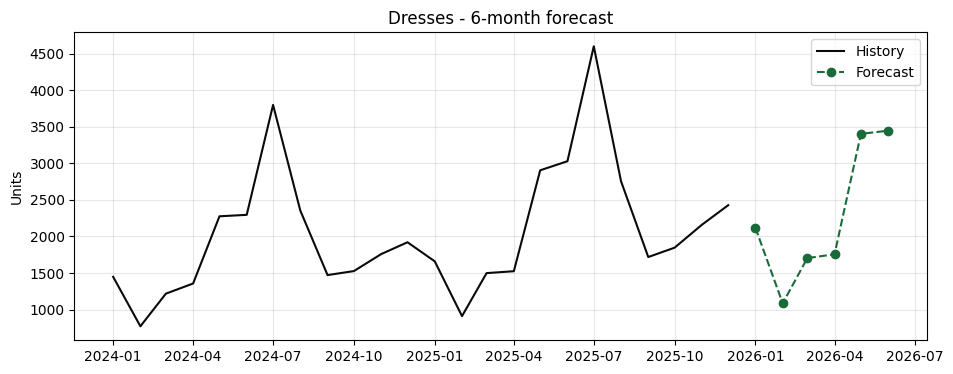

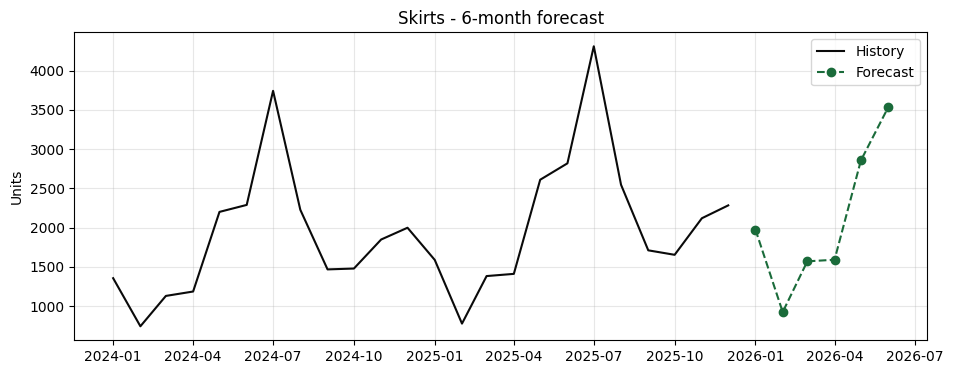

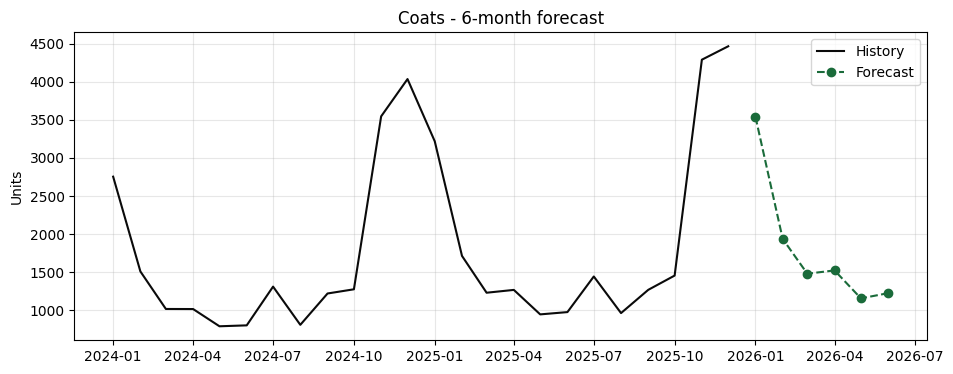

In [12]:
# History + forecast for the top-4 categories by volume
top_cats = df.groupby("category")["total_quantity"].sum().sort_values(ascending=False).head(4).index
for cat in top_cats:
    h = df[df["category"] == cat].sort_values("date")
    fc = future[future["category"] == cat].sort_values("date")
    plt.figure(figsize=(11, 4))
    plt.plot(h["date"], h["total_quantity"], color="#0a0a0a", label="History")
    plt.plot(fc["date"], fc["forecast"], color="#1a6b3a", linestyle="--", marker="o", label="Forecast")
    plt.title(f"{cat} - {HORIZON}-month forecast"); plt.ylabel("Units")
    plt.legend(); plt.grid(alpha=.3); plt.show()

In [13]:
import joblib, os
os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/xgboost_demand_forecast.pkl")
joblib.dump(feature_cols, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [14]:
os.makedirs("../data", exist_ok=True)

export_df = df[["year", "month", "category", "total_quantity", "promo_share", "discount_rate"]].copy()
export_df.to_csv("../data/history.csv", index=False)

print(f"Saved {len(export_df)} rows to data/history.csv")
print(export_df.head())

Saved 288 rows to data/history.csv
   year  month category  total_quantity  promo_share  discount_rate
0  2024      1     Bags             746     0.975871       0.288730
1  2024      2     Bags             412     0.000000       0.001081
2  2024      3     Bags             643     0.000000       0.001240
3  2024      4     Bags             682     0.000000      -0.000855
4  2024      5     Bags             576     0.000000       0.001076
